In [1]:
import numpy as np
import matplotlib.pyplot as plt
import ase
import abtem
from ptychobench_3d.grid import SimulationGrid, prepare_potential
from ptychobench_3d.benchmark import run_benchmark
from ptychobench_3d.operators import (
    ParaxialOperatorMF,
    FeitFleckOperatorMF,
    LinDudaOperatorMF,
    StandardMultisliceOperator,
    StrangMultisliceOperator,
)
import torch
import os
import urllib.request
import ase.io

# Setup PyTorch device to use Apple MPS (Metal Performance Shaders) if available
DEVICE = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

In [2]:



def create_atomic_structure(slices):
    carbon_matrix = ase.build.bulk('C', cubic=True)
    carbon_matrix *= (8, 8, slices)

    # Calculate the geometric center of the supercell
    cell_center = carbon_matrix.get_cell().sum(axis=0) / 2.0

    # Define the radius of the Gold nanoparticle (in Angstroms)
    np_radius = 8.0 

    # Create a cavity in the Carbon matrix
    # We add a 1.0 A buffer to the radius to prevent unphysical overlaps between C and Au atoms
    distances_C = np.linalg.norm(carbon_matrix.positions - cell_center, axis=1)
    carbon_matrix = carbon_matrix[distances_C > (np_radius + 1.0)]

    # Create a bulk block of Gold
    au_bulk = ase.build.bulk('Au', cubic=True)

    # Estimate how many repetitions of the Au unit cell are needed to cover the nanoparticle
    reps = int(np.ceil((np_radius * 2) / au_bulk.cell[0,0])) + 2
    au_np = au_bulk * (reps, reps, reps)

    # Shift the Gold block so its center perfectly aligns with the Carbon cell center
    au_center = au_np.get_cell().sum(axis=0) / 2.0
    au_np.translate(cell_center - au_center)

    # Carve out the spherical nanoparticle from the Gold block
    distances_Au = np.linalg.norm(au_np.positions - cell_center, axis=1)
    au_np = au_np[distances_Au <= np_radius]

    # Combine the carved Carbon matrix and the Gold nanoparticle
    atoms = carbon_matrix + au_np

    # Apply small random thermal displacements (Thermal Diffuse Scattering)
    atoms.rattle(stdev=0.05, seed=42)

    return atoms

def create_dna_structure():
    pdb_file = "1BNA.pdb"
    if not os.path.exists(pdb_file):
        print("Downloading 1BNA.pdb from RCSB Protein Data Bank...")
        urllib.request.urlretrieve("https://files.rcsb.org/download/1BNA.pdb", pdb_file)

    # Load the DNA molecule using ASE
    dna = ase.io.read(pdb_file)

    # Strip out any erratic unit cell data from the PDB and create a clean, orthogonal bounding box
    positions = dna.get_positions()
    min_pos = positions.min(axis=0)
    max_pos = positions.max(axis=0)

    # Add 10 Å of padding (5 Å on all sides)
    cell_size = (max_pos - min_pos) + 10.0
    dna.set_cell(cell_size)
    dna.center()

    # Replicate the DNA to simulate a thick macromolecular fibril
    atoms = dna * (1,1,1)
    return atoms

def create_potential_grid():
    pdb_file = "1KX5.pdb"
    if not os.path.exists(pdb_file):
        print(f"Downloading {pdb_file} from RCSB Protein Data Bank...")
        urllib.request.urlretrieve(f"https://files.rcsb.org/download/{pdb_file}", pdb_file)

    # Load the macromolecule using ASE
    macromolecule = ase.io.read(pdb_file)

    # Strip out erratic unit cell data from the PDB and create a clean, orthogonal bounding box
    positions = macromolecule.get_positions()
    min_pos = positions.min(axis=0)
    max_pos = positions.max(axis=0)

    # Add 10 Å of padding (5 Å on all sides) to prevent edge wrapping
    cell_size = (max_pos - min_pos) + 10.0
    macromolecule.set_cell(cell_size)
    macromolecule.center()

    # We only need 1 unit of this massive complex
    atoms = macromolecule * (1, 1, 1)
    return atoms

Building atomic structure...

--- Running native abtem multislice propagation ---


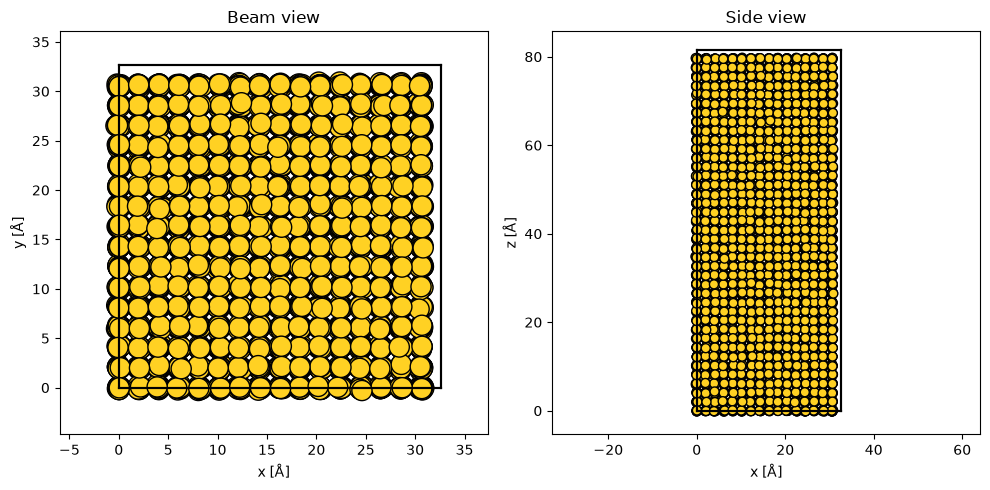

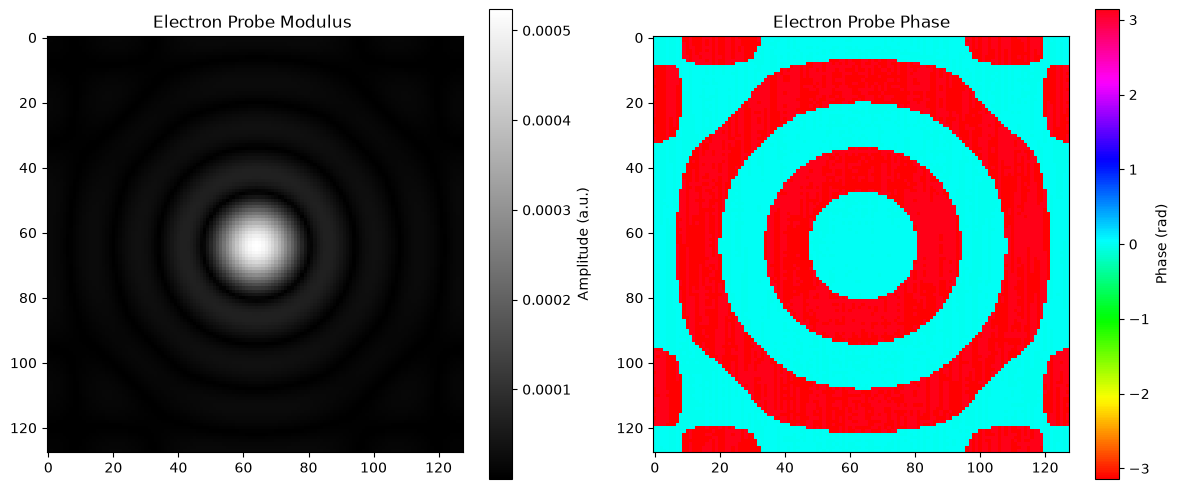

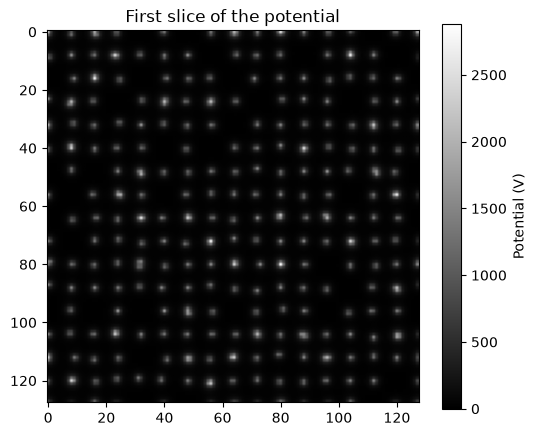

In [3]:

pixels = 128
slices = 20

# ---------------------------------------------------------
# 1. Setup the Atomic Model using ASE/abtem
# ---------------------------------------------------------
print("Building atomic structure...")

# Create a dense, heavy Gold (Au) crystal in a cubic lattice
atoms = ase.build.bulk('Au', cubic=True)

# Electrons will experience massive dynamic scattering down these columns
atoms *= (8, 8, slices) 

# Apply random thermal displacements
atoms.rattle(stdev=0.1, seed=42)

# # # Create a light element (Carbon) in a cubic lattice
# # atoms = ase.build.bulk('C', cubic=True)

# # Electrons will experience massive dynamic scattering down these columns
# atoms *= (8, 8, slices) 

# # Apply random thermal displacements
# atoms.rattle(stdev=0.1, seed=42)


# # Create structure of carbon with gold nanoparticles (AuNPs) embedded in a carbon matrix
# atoms = create_atomic_structure(slices)


# Visualize the atomic structure (Beam View and Side View)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

# Beam view (XY plane is the default)
abtem.show_atoms(atoms, plane="xy", ax=ax1)
ax1.set_title("Beam view")

# Side view (XZ plane)
abtem.show_atoms(atoms, plane="xz", ax=ax2)
ax2.set_title("Side view")

fig.tight_layout()


# Physical dimensions of the supercell
length = atoms.cell[0, 0]
depth = atoms.cell[2, 2]

# Use isotropic sampling based on the larger dimension
sampling = length / pixels

# Create 10 slices through the specimen thickness
slice_thickness = depth / slices

potential = abtem.Potential(
    atoms,
    sampling=sampling,
    slice_thickness=slice_thickness,
    projection="infinite",
    parametrization="lobato",
)

built_potential = potential.build()
potential_array = built_potential.array[:, :pixels, :pixels]


# ---------------------------------------------------------
# 2. Setup 3D Grid Parameters
# --------------------------------------------------------


probe = abtem.Probe(
    energy=30e3,  # Electron energy in eV          
    semiangle_cutoff=10.0,  
    extent=length,          # Matches the real-space box of the atoms
    gpts=pixels                 
)

# Build complex probe wavefield
probe_waves = probe.build()
probe_complex = np.squeeze(probe_waves.array)

# Calculate Modulus and Phase
probe_modulus = np.abs(probe_complex)
probe_phase = np.angle(probe_complex)

# Plot Modulus and Phase side-by-side
fig, (ax_mod, ax_phase) = plt.subplots(1, 2, figsize=(12, 5))

im1 = ax_mod.imshow(probe_modulus, cmap='gray')
ax_mod.set_title("Electron Probe Modulus ")
fig.colorbar(im1, ax=ax_mod, label="Amplitude (a.u.)")

im2 = ax_phase.imshow(probe_phase, cmap='hsv', vmin=-np.pi, vmax=np.pi)
ax_phase.set_title("Electron Probe Phase")
fig.colorbar(im2, ax=ax_phase, label="Phase (rad)")

plt.tight_layout()



grid_params = {
    "probe_field": probe_complex,
    "probe_abtem": probe,
    "L": length,
    "z_prop": depth,
    "N": pixels,
    "Nz": slices
}

grid = SimulationGrid(**grid_params)


# ---------------------------------------------------------
# Convert Electrostatic Potential to Refractive Index / Interaction Term (E)
# ---------------------------------------------------------

# Relativistic beam energy in eV
E_0 = probe.energy 


plt.figure(figsize=(6, 5))
plt.imshow(potential_array[0], cmap='gray')
plt.title("First slice of the potential")
plt.colorbar(label="Potential (V)")


print("\n--- Running native abtem multislice propagation ---")

# abtem handles the propagation natively using the split-step approximation
potential_abtem = abtem.PotentialArray(
    array=potential_array, 
    slice_thickness=[grid.dz for _ in range(grid.Nz)], 
    sampling=sampling,
    extent=grid.L,
    exit_planes=range(grid.Nz-1) 
)


# Run the multislice propagation with abtem
abtem_waves_3d = probe_waves.multislice(potential_abtem)
abtem_wavefield_complex = np.squeeze(abtem_waves_3d.array)
abtem_wavefield_complex = np.concatenate(
    [probe_complex[np.newaxis, ...], abtem_wavefield_complex], 
    axis=0
)

# Generate the correct Krylov input array
E_array = prepare_potential(grid, potential_array)


In [4]:
result = run_benchmark(grid, E_array, operators=[
    LinDudaOperatorMF,
    ParaxialOperatorMF,
    FeitFleckOperatorMF,
    StandardMultisliceOperator,
    StrangMultisliceOperator,
])
# # Add Abtem wavefield history keys to the plot
# result.wavefield_history['abtem'] = abtem_wavefield_complex
result.print_summary()

18:10:31 | --- Starting full propagation for: Lin/Duda_mf ---
18:10:33 | Operator 'Lin/Duda_mf' Summary:
  - Time:       1.3863 seconds
  - Peak RAM:   0.60 MB
  - Peak VRAM:  ~2.64 MB (MPS Current)
18:10:33 | --- Starting full propagation for: Paraxial_mf ---
18:10:34 | Operator 'Paraxial_mf' Summary:
  - Time:       1.3162 seconds
  - Peak RAM:   0.59 MB
  - Peak VRAM:  ~2.77 MB (MPS Current)
18:10:34 | --- Starting full propagation for: Feit/Fleck_mf ---
18:10:35 | Operator 'Feit/Fleck_mf' Summary:
  - Time:       1.2679 seconds
  - Peak RAM:   0.59 MB
  - Peak VRAM:  ~2.83 MB (MPS Current)
18:10:35 | --- Starting full propagation for: Standard_Multislice ---
18:10:35 | Operator 'Standard_Multislice' Summary:
  - Time:       0.0313 seconds
  - Peak RAM:   0.59 MB
  - Peak VRAM:  ~2.83 MB (MPS Current)
18:10:35 | --- Starting full propagation for: Strang_Multislice ---
18:10:35 | Operator 'Strang_Multislice' Summary:
  - Time:       0.0305 seconds
  - Peak RAM:   0.59 MB
  - Peak VRA


Wavefield Errors (RMSE relative to Exact_mf):
  Feit/Fleck_mf       : 3.787731e-06
  Lin/Duda_mf         : 3.837219e-06
  Paraxial_mf         : 3.927893e-06
  Strang_Multislice   : 2.556834e-05
  Standard_Multislice : 2.845690e-05
---------------------------------------------

Detector Errors (RMSE relative to Exact_mf):
  Paraxial_mf         : 1.001888e-05
  Lin/Duda_mf         : 1.042323e-05
  Feit/Fleck_mf       : 1.156040e-05
  Strang_Multislice   : 2.434908e-04
  Standard_Multislice : 2.437258e-04
---------------------------------------------

Detector Errors (Max Error relative to Exact_mf):
  Paraxial_mf         : 1.919516e-04
  Lin/Duda_mf         : 2.528745e-04
  Feit/Fleck_mf       : 3.097141e-04
  Standard_Multislice : 5.770493e-03
  Strang_Multislice   : 5.775441e-03
---------------------------------------------


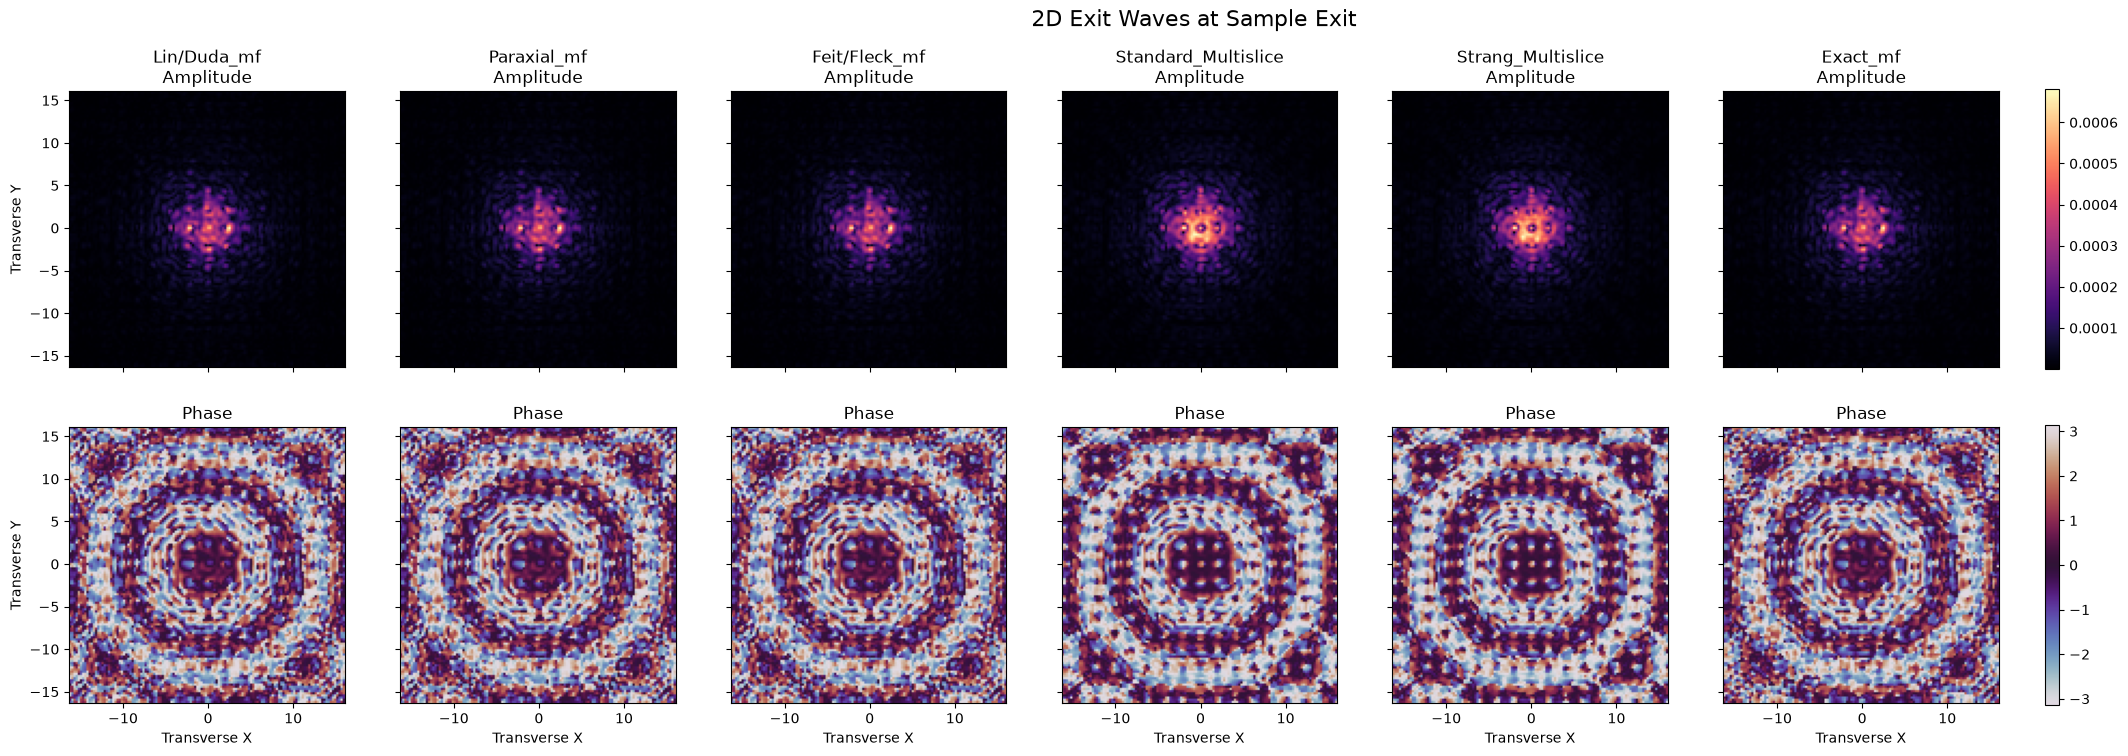

In [5]:
# --- New 3D Visualizations ---
# Show the full 2D exit wave (Phase and Amplitude) at the final Z step
fig_exit_2d = result.plot_exitwave_2D()

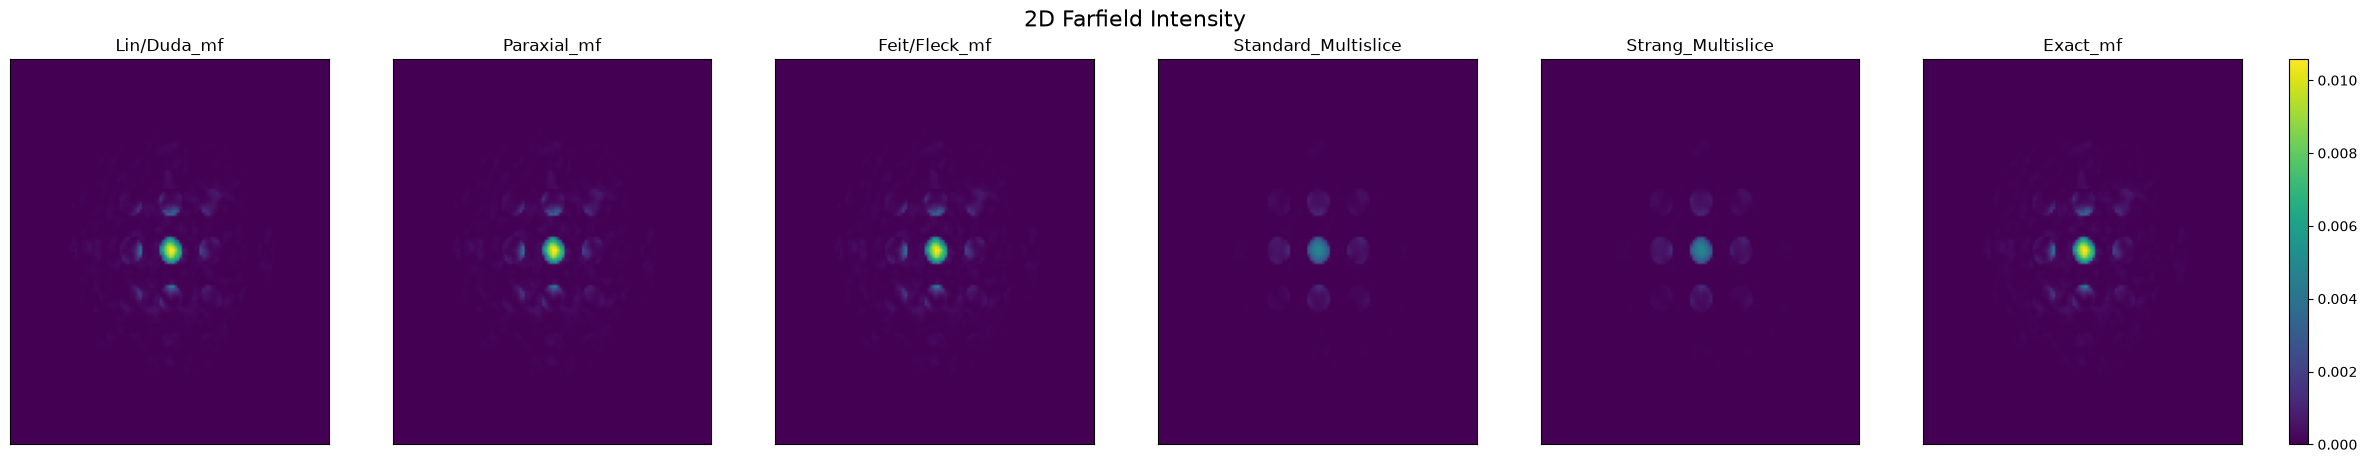

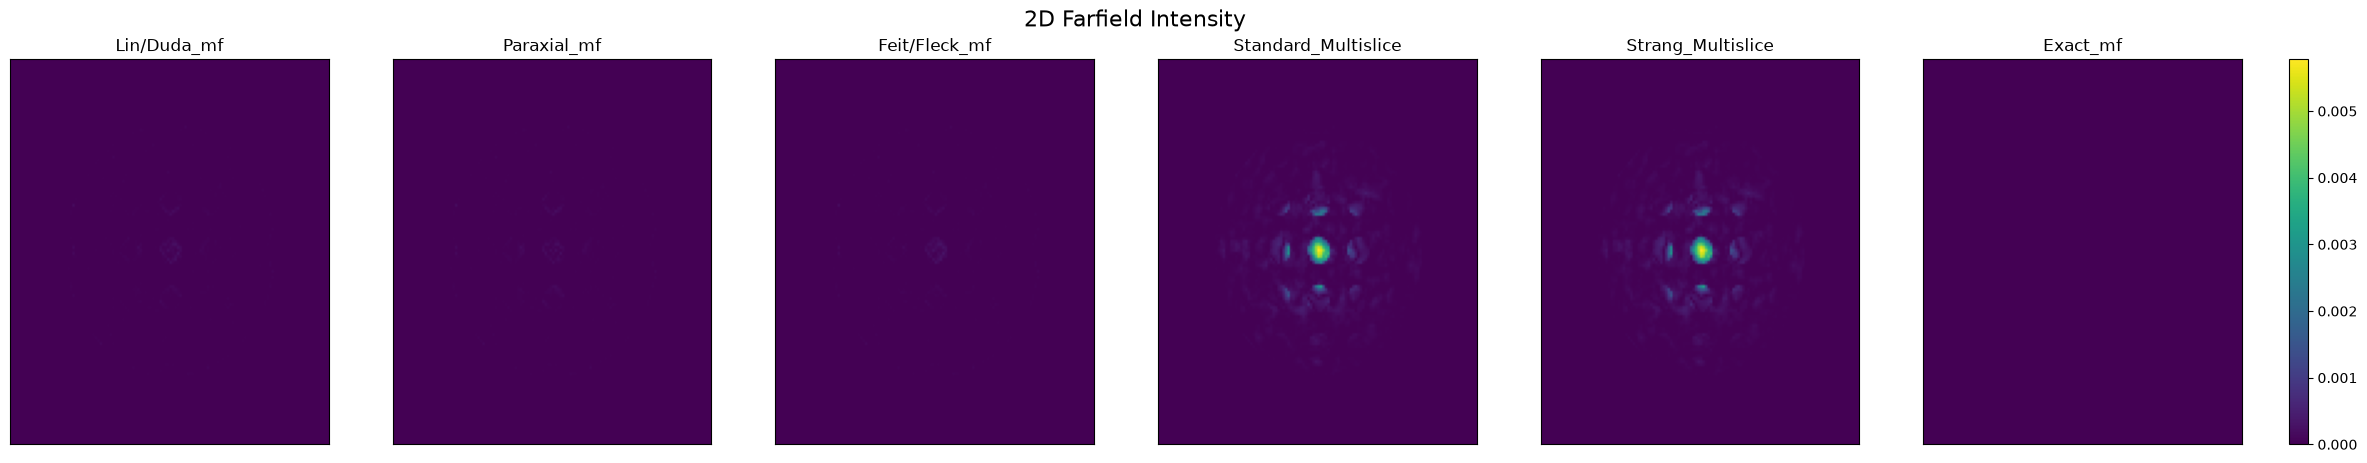

In [6]:
# Show the full 2D farfield intensity
fig_ff_2d = result.plot_farfield_2D(mode="intensity",log_scale=False)
# Show the full 2D farfield intensity
fig_ff_2d = result.plot_farfield_2D(mode="intensity",log_scale=False, error_map=True)

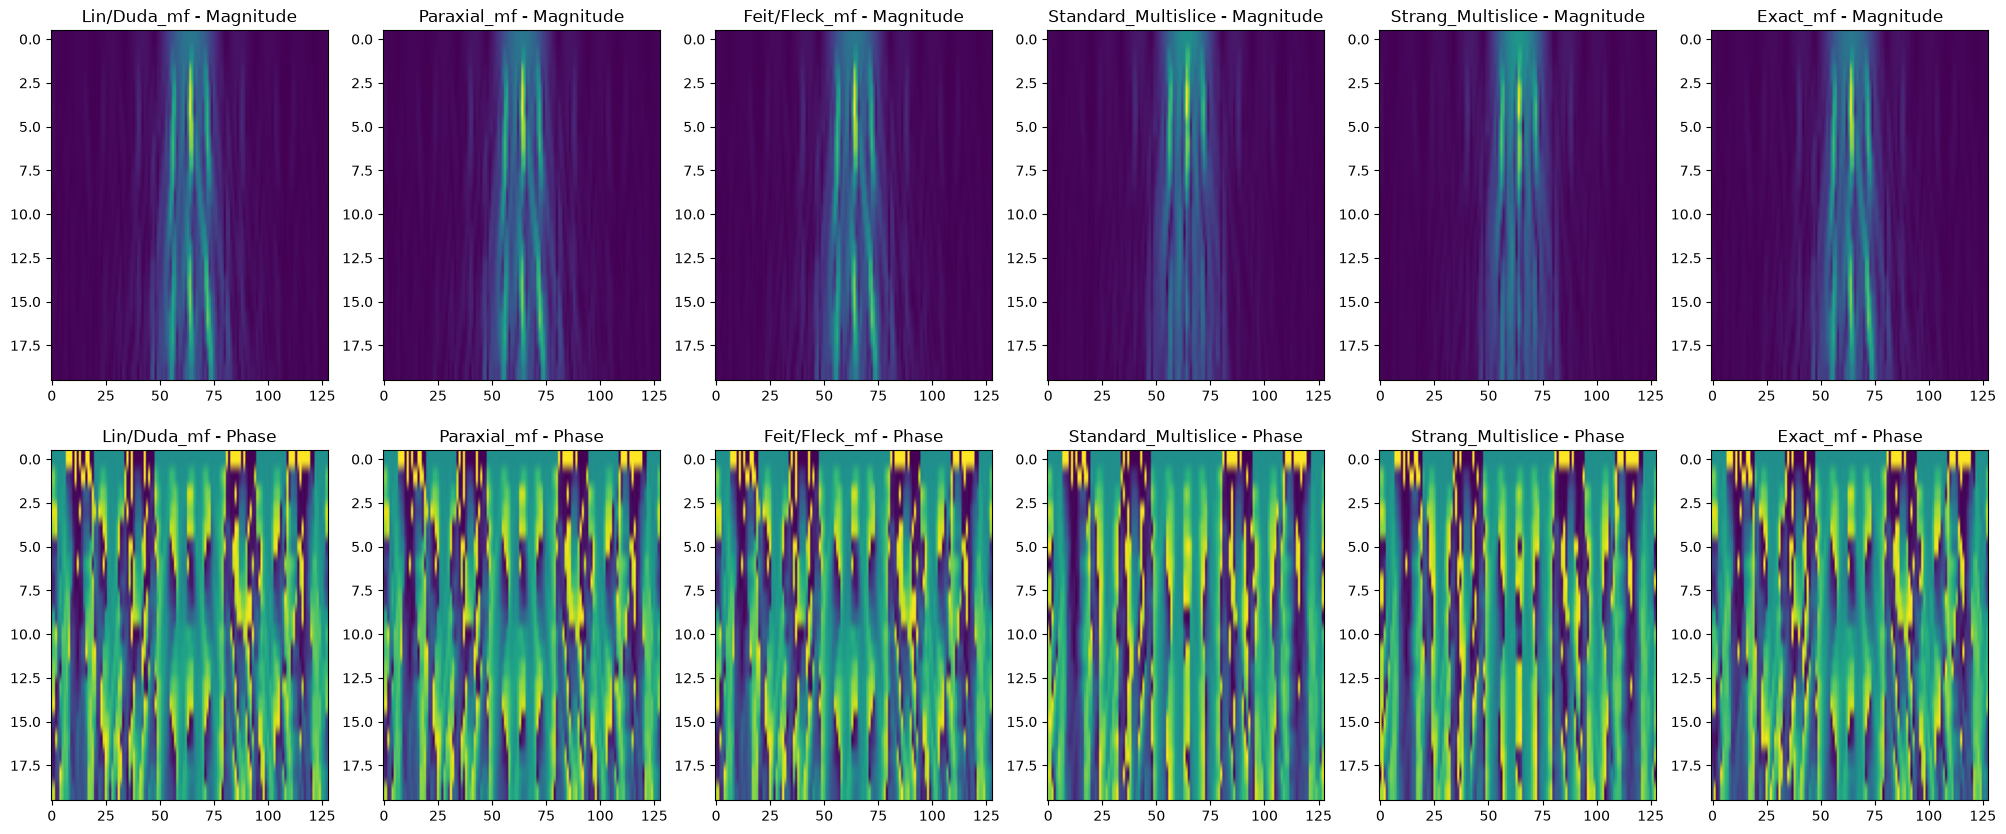

In [7]:
%matplotlib inline
# Plot cross-sections of the field
num_operators = len(result.wavefield_history.keys())
fig, ax = plt.subplots(2, num_operators, figsize=(25, 10))

for i, operator_name in enumerate(result.wavefield_history.keys()):
    wavefield = result.wavefield_history[operator_name]
    ax[0, i].imshow(np.abs(wavefield[:, :, pixels//2]), aspect='auto')
    ax[0, i].set_title(f"{operator_name} - Magnitude")
    ax[1, i].imshow(np.angle(wavefield[:, :, pixels//2]), aspect='auto')
    ax[1, i].set_title(f"{operator_name} - Phase")


(<Figure size 1000x800 with 4 Axes>,
 {'x_slider': <matplotlib.widgets.Slider at 0x31095f380>,
  'y_slider': <matplotlib.widgets.Slider at 0x31d923110>})

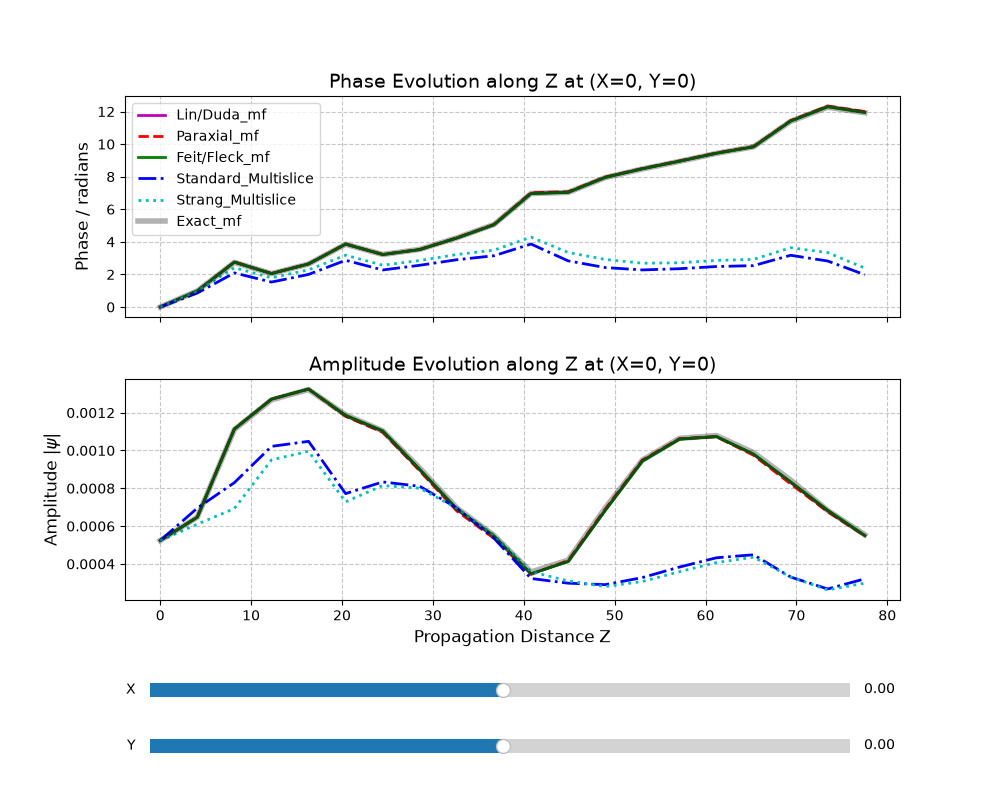

In [8]:
%matplotlib widget
result.plot_evolution_slider()